<a href="https://colab.research.google.com/github/chitrasavithri176-cmyk/python-ex/blob/main/hospital_readmission_risk_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df=pd.read_csv("hospital_readmission_risk_dataset_2026_v1_18000rows (1).csv")
print(df.shape)

(18000, 25)


In [ ]:
# Display the first 10 records

print(df.head(10))

   Age  Gender Insurance_Type  Socioeconomic_Risk_Score  \
0   71    Male       Medicare                         9   
1   34  Female        Private                         8   
2   80    Male       Medicare                         2   
3   40  Female        Private                         7   
4   43    Male       Medicaid                         5   
5   22    Male       Medicaid                         4   
6   41    Male       Medicaid                         4   
7   72    Male        Private                         4   
8   21    Male       Medicare                         9   
9   49    Male       Medicare                         7   

   Previous_Admissions_6M  Previous_Readmissions_1Y  \
0                       2                         0   
1                       4                         0   
2                       1                         3   
3                       2                         0   
4                       2                         1   
5                   

In [ ]:
# Display the last 10 reacords

print(df.tail(10))

       Age  Gender Insurance_Type  Socioeconomic_Risk_Score  \
17990   65  Female        Private                         8   
17991   62  Female       Medicare                         9   
17992   21  Female        Private                         4   
17993   73    Male       Medicaid                         2   
17994   54    Male       Medicare                         2   
17995   71    Male       Medicaid                         4   
17996   52  Female       Medicare                         6   
17997   70    Male       Medicare                         6   
17998   45  Female        Private                         2   
17999   81  Female       Medicaid                         1   

       Previous_Admissions_6M  Previous_Readmissions_1Y  \
17990                       1                         1   
17991                       1                         1   
17992                       3                         1   
17993                       2                         2   
17994      

In [ ]:
# Display all column names

print (df.columns)

Index(['Age', 'Gender', 'Insurance_Type', 'Socioeconomic_Risk_Score',
       'Previous_Admissions_6M', 'Previous_Readmissions_1Y',
       'Time_Since_Last_Discharge', 'Length_of_Stay', 'Admission_Type',
       'Primary_Diagnosis_Group', 'Comorbidity_Index', 'Chronic_Disease_Count',
       'ICU_Stay_Flag', 'Severity_Score', 'HbA1c_Level', 'Creatinine_Level',
       'Hemoglobin_Level', 'Average_Systolic_BP', 'Number_of_Medications',
       'Medication_Change_Count', 'High_Risk_Medication_Flag',
       'Followup_Appointment_Scheduled', 'Discharge_Disposition',
       'Medication_Adherence_Score', 'Readmitted_Within_30_Days'],
      dtype='object')


In [ ]:
# Display dataset information

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 25 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             18000 non-null  int64  
 1   Gender                          18000 non-null  object 
 2   Insurance_Type                  18000 non-null  object 
 3   Socioeconomic_Risk_Score        18000 non-null  int64  
 4   Previous_Admissions_6M          18000 non-null  int64  
 5   Previous_Readmissions_1Y        18000 non-null  int64  
 6   Time_Since_Last_Discharge       18000 non-null  int64  
 7   Length_of_Stay                  18000 non-null  int64  
 8   Admission_Type                  18000 non-null  object 
 9   Primary_Diagnosis_Group         18000 non-null  object 
 10  Comorbidity_Index               18000 non-null  int64  
 11  Chronic_Disease_Count           18000 non-null  int64  
 12  ICU_Stay_Flag                   

In [ ]:
# Find missing values in easch columns

print(df.isnull().sum())

Age                               0
Gender                            0
Insurance_Type                    0
Socioeconomic_Risk_Score          0
Previous_Admissions_6M            0
Previous_Readmissions_1Y          0
Time_Since_Last_Discharge         0
Length_of_Stay                    0
Admission_Type                    0
Primary_Diagnosis_Group           0
Comorbidity_Index                 0
Chronic_Disease_Count             0
ICU_Stay_Flag                     0
Severity_Score                    0
HbA1c_Level                       0
Creatinine_Level                  0
Hemoglobin_Level                  0
Average_Systolic_BP               0
Number_of_Medications             0
Medication_Change_Count           0
High_Risk_Medication_Flag         0
Followup_Appointment_Scheduled    0
Discharge_Disposition             0
Medication_Adherence_Score        0
Readmitted_Within_30_Days         0
dtype: int64


In [ ]:
# count total patients

print(len(df))

18000


In [ ]:
# Count male and female patients

print(df["Gender"].value_counts())

Gender
Male      9086
Female    8914
Name: count, dtype: int64


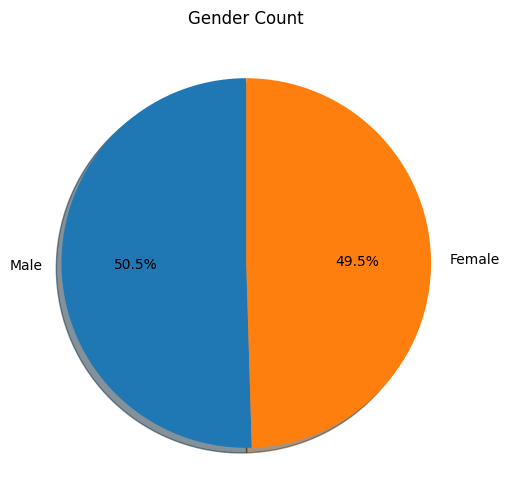

In [ ]:
gender=df["Gender"].value_counts()
import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
plt.pie(gender,
        labels=gender.index,
        autopct="%1.1f%%",
        shadow=True,
        startangle=90)
plt.title("Gender Count")
plt.show()

In [ ]:
# count patients readmitted with in 30 days

print(df["Readmitted_Within_30_Days"].value_counts())

Readmitted_Within_30_Days
1    13349
0     4651
Name: count, dtype: int64


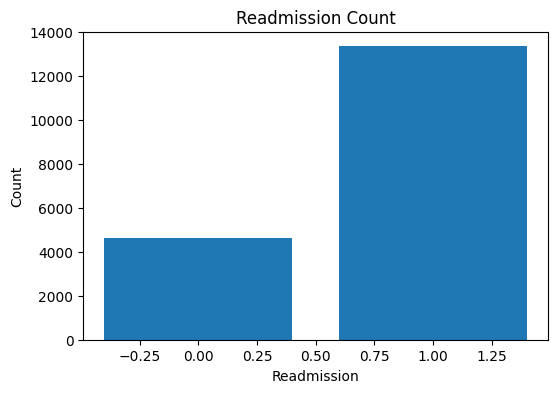

In [ ]:
# Readmission count

import pandas as pd
import matplotlib.pyplot as plt

readmission=df["Readmitted_Within_30_Days"].value_counts()
plt.figure(figsize=(6,4))
plt.bar(readmission.index,readmission.values)
plt.xlabel("Readmission")
plt.ylabel("Count")
plt.title("Readmission Count")
plt.show()

10.049444444444445


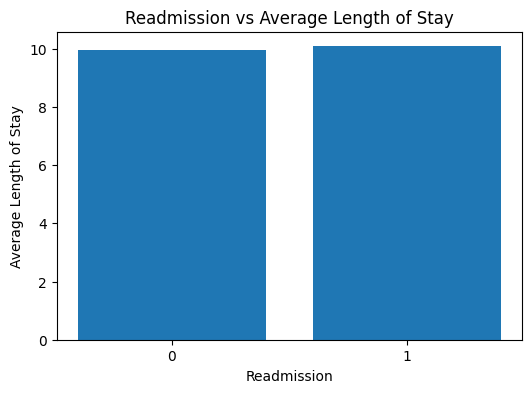

In [ ]:
# Average length of stay

print(df["Length_of_Stay"].mean())

los=df.groupby("Readmitted_Within_30_Days")["Length_of_Stay"].mean()

plt.figure(figsize=(6,4))
plt.bar(los.index.astype(str),los.values)
plt.xlabel("Readmission")
plt.ylabel("Average Length of Stay")
plt.title("Readmission vs Average Length of Stay")
plt.show()


Primary_Diagnosis_Group
Other          3708
Infection      3615
Diabetes       3590
Respiratory    3551
Cardiac        3536
Name: count, dtype: int64


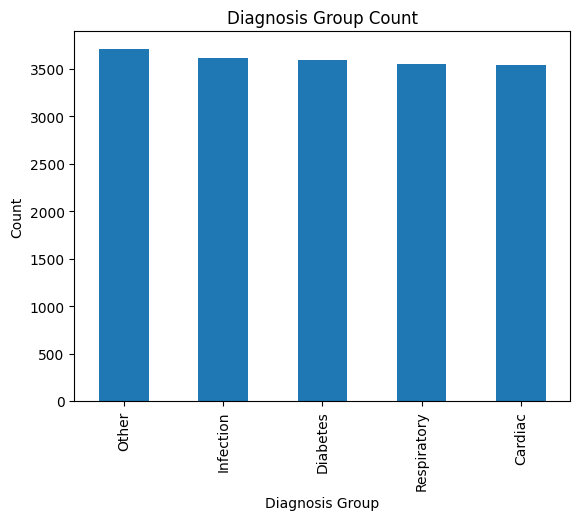

In [ ]:
# count patient in each diagnosis group

diagnosis = df["Primary_Diagnosis_Group"].value_counts()
print(diagnosis)


diagnosis.head(10).plot(kind="bar")
plt.xlabel("Diagnosis Group")
plt.ylabel("Count")
plt.title("Diagnosis Group Count")
plt.show()

In [ ]:
# find the diagnosis group with the highest readmission rate

print(df.groupby("Primary_Diagnosis_Group")["Readmitted_Within_30_Days"].mean()*100)

Primary_Diagnosis_Group
Cardiac        74.604072
Diabetes       73.314763
Infection      75.269710
Other          74.083064
Respiratory    73.528583
Name: Readmitted_Within_30_Days, dtype: float64


In [ ]:
# Average severity score

print(df["Severity_Score"].mean())

5.0055


In [ ]:
# Display the top 10 highest severity patients

top10=df.sort_values(by="Severity_Score",ascending=False).head(10)
print(top10.head(10))

       Age  Gender Insurance_Type  Socioeconomic_Risk_Score  \
4       43    Male       Medicaid                         5   
14000   85    Male        Private                         7   
14001   34    Male       Medicaid                         2   
45      66  Female       Medicare                         7   
18      68    Male        Private                         5   
13993   79  Female        Private                         5   
13994   85    Male        Private                         5   
13970   78    Male       Medicaid                         8   
13972   65  Female       Medicare                         9   
13978   50    Male        Private                         9   

       Previous_Admissions_6M  Previous_Readmissions_1Y  \
4                           2                         1   
14000                       1                         1   
14001                       1                         2   
45                          3                         2   
18         

Readmitted_Within_30_Days
0     9.951408
1    10.083602
Name: Length_of_Stay, dtype: float64


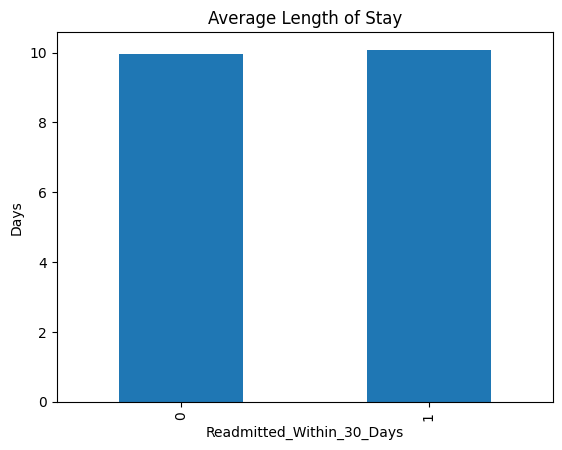

In [ ]:
# Average length of stay by readmission status

los=df.groupby("Readmitted_Within_30_Days")["Length_of_Stay"].mean()
print(los)

los.plot(kind="bar")
plt.title("Average Length of Stay")
plt.ylabel("Days")
plt.show()

0.7016744444444445


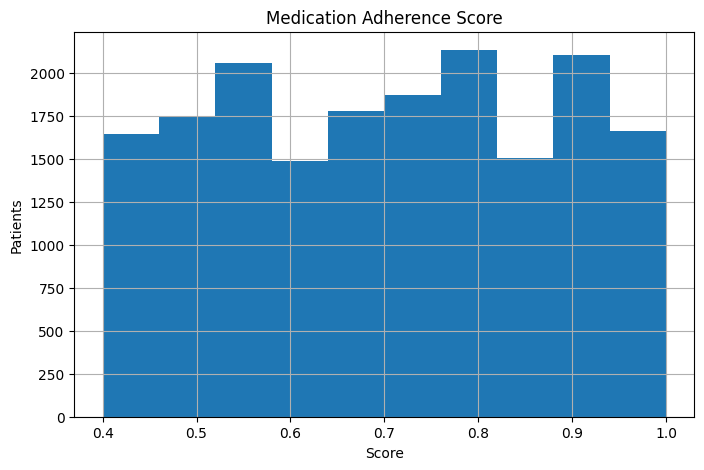

In [ ]:
# Meadication Adherence score

print(df["Medication_Adherence_Score"].mean())

plt.figure(figsize=(8,5))
plt.hist(df["Medication_Adherence_Score"],bins=10)
plt.xlabel("Score")
plt.ylabel("Patients")
plt.title("Medication Adherence Score")
plt.grid()
plt.show()

Readmitted_Within_30_Days
0    0.705388
1    0.700381
Name: Medication_Adherence_Score, dtype: float64


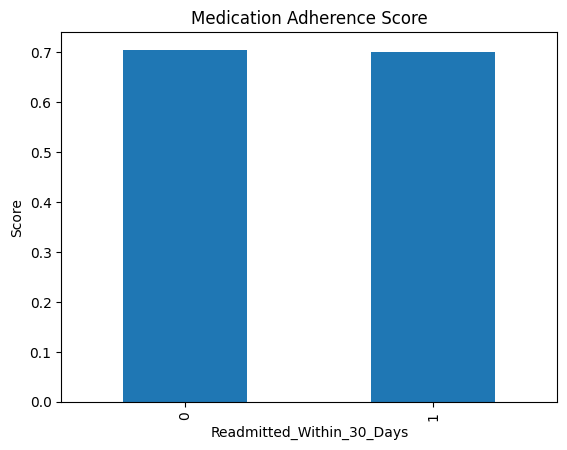

In [ ]:
# Meadication adherence affect readmission

adherence=df.groupby("Readmitted_Within_30_Days")["Medication_Adherence_Score"].mean()
print(adherence)

adherence.plot(kind="bar")
plt.title("Medication Adherence Score")
plt.ylabel("Score")
plt.show()

In [7]:
import pandas as pd
df = pd.read_csv("hospital_readmission_risk_dataset_2026_v1_18000rows (1).csv")
print(f"Mean of Comorbidity_Index: {df['Comorbidity_Index'].mean()}")

Mean of Comorbidity_Index: 2.4755555555555557


Age_Group
(0, 20]      71.600000
(20, 40]     73.438992
(40, 60]     73.301549
(60, 80]     74.669518
(80, 100]    76.788009
Name: Readmitted_Within_30_Days, dtype: float64


/tmp/ipykernel_1595/931853773.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result=df.groupby("Age_Group")["Readmitted_Within_30_Days"].mean()*100


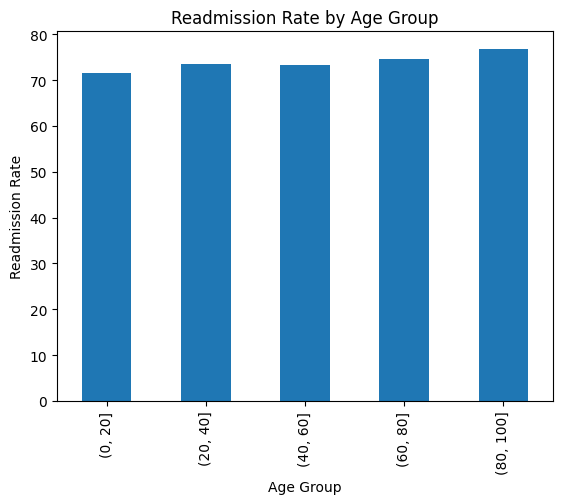

In [ ]:
# Age group has the highest readmission rate

df["Age_Group"]=pd.cut(df["patient_Age"],bins=[0,20,40,60,80,100])
result=df.groupby("Age_Group")["Readmitted_Within_30_Days"].mean()*100
print(result)

result.plot(kind="bar")
plt.title("Readmission Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Readmission Rate")
plt.show()



ICU_Stay_Flag
0    14440
1     3560
Name: count, dtype: int64


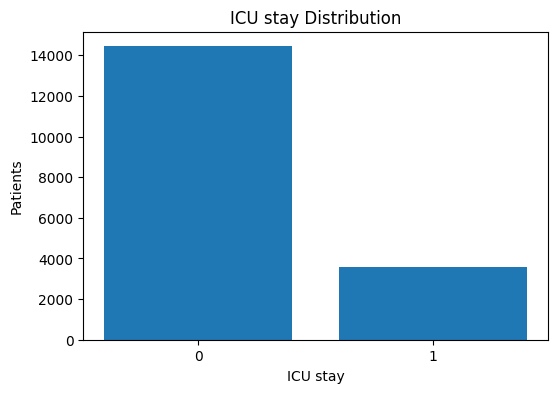

In [ ]:
# count the ICU and Non-ICU patients
icu = df["ICU_Stay_Flag"].value_counts()
print(icu)

plt.figure(figsize=(6,4))
plt.bar(icu.index.astype(str),icu.values)
plt.title("ICU stay Distribution")
plt.xlabel("ICU stay")
plt.ylabel("Patients")
plt.show()

ICU_Stay_Flag
0    73.580332
1    76.516854
Name: Readmitted_Within_30_Days, dtype: float64


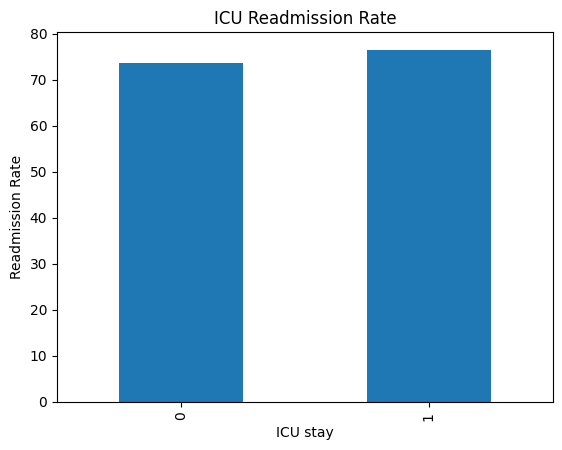

In [ ]:
# ICU readmission rate

icu_readmission=df.groupby("ICU_Stay_Flag")["Readmitted_Within_30_Days"].mean()*100
print(icu_readmission)

icu_readmission.plot(kind="bar")
plt.title("ICU Readmission Rate")
plt.xlabel("ICU stay")
plt.ylabel("Readmission Rate")
plt.show()


In [ ]:
# Display only Age,Gender and Diagnosis columns

print(df[["Age","Gender","Primary_Diagnosis_Group"]])

       Age  Gender Primary_Diagnosis_Group
0       71    Male               Infection
1       34  Female               Infection
2       80    Male             Respiratory
3       40  Female                 Cardiac
4       43    Male               Infection
...    ...     ...                     ...
17995   71    Male                   Other
17996   52  Female                 Cardiac
17997   70    Male             Respiratory
17998   45  Female                 Cardiac
17999   81  Female                 Cardiac

[18000 rows x 3 columns]


In [ ]:
# Display all unique Diagnosis Groups

print(df["Primary_Diagnosis_Group"].unique())

['Infection' 'Respiratory' 'Cardiac' 'Other' 'Diabetes']


In [ ]:
# patients older than 60 with Severity score greater than 7

result=df[(df["Age"]>60)&(df["Severity_Score"]>7)]
print(result)

       Age  Gender Insurance_Type  Socioeconomic_Risk_Score  \
0       71    Male       Medicare                         9   
7       72    Male        Private                         4   
12      83    Male        Private                         9   
16      77  Female       Medicare                         4   
18      68    Male        Private                         5   
...    ...     ...            ...                       ...   
17946   87  Female       Medicaid                         5   
17971   87  Female        Private                         4   
17986   79  Female        Private                         2   
17995   71    Male       Medicaid                         4   
17997   70    Male       Medicare                         6   

       Previous_Admissions_6M  Previous_Readmissions_1Y  \
0                           2                         0   
7                           1                         0   
12                          1                         1   
16     

In [ ]:
# Rename the "Age" column to "patient_Age"

df=df.rename(columns={"Age":"patient_Age"})
print(df.columns)

Index(['patient_Age', 'Gender', 'Insurance_Type', 'Socioeconomic_Risk_Score',
       'Previous_Admissions_6M', 'Previous_Readmissions_1Y',
       'Time_Since_Last_Discharge', 'Length_of_Stay', 'Admission_Type',
       'Primary_Diagnosis_Group', 'Comorbidity_Index', 'Chronic_Disease_Count',
       'ICU_Stay_Flag', 'Severity_Score', 'HbA1c_Level', 'Creatinine_Level',
       'Hemoglobin_Level', 'Average_Systolic_BP', 'Number_of_Medications',
       'Medication_Change_Count', 'High_Risk_Medication_Flag',
       'Followup_Appointment_Scheduled', 'Discharge_Disposition',
       'Medication_Adherence_Score', 'Readmitted_Within_30_Days'],
      dtype='object')


In [ ]:
df["Age_Category"]=df["patient_Age"].apply(lambda x: "Senior" if x>=60 else "Adult")
print(df.head())

   patient_Age  Gender Insurance_Type  Socioeconomic_Risk_Score  \
0           71    Male       Medicare                         9   
1           34  Female        Private                         8   
2           80    Male       Medicare                         2   
3           40  Female        Private                         7   
4           43    Male       Medicaid                         5   

   Previous_Admissions_6M  Previous_Readmissions_1Y  \
0                       2                         0   
1                       4                         0   
2                       1                         3   
3                       2                         0   
4                       2                         1   

   Time_Since_Last_Discharge  Length_of_Stay Admission_Type  \
0                         96              15         Urgent   
1                         58              12         Urgent   
2                         25              11         Urgent   
3             

In [ ]:
# Number of High Risk patient

print(df["High_Risk_Medication_Flag"].value_counts())

High_Risk_Medication_Flag
0    12560
1     5440
Name: count, dtype: int64


In [ ]:
# Create a new CSV file containing only high-risk patients

high_risk=df[df["Severity_Score"]>=8]
high_risk.to_csv("High_Risk_Patients.csv",index=False)
print("High-risk patient file created successfully.")

High-risk patient file created successfully.


In [ ]:
# Display rows 10-20 using iloc

print(df.iloc[10:21])

    patient_Age  Gender Insurance_Type  Socioeconomic_Risk_Score  \
10           57  Female       Medicare                         7   
11           21    Male        Private                         4   
12           83    Male        Private                         9   
13           79  Female       Medicaid                         8   
14           40  Female       Medicare                         4   
15           52    Male        Private                         6   
16           77  Female       Medicare                         4   
17           41  Female       Medicare                         1   
18           68    Male        Private                         5   
19           78    Male        Private                         3   
20           61  Female       Medicaid                         1   

    Previous_Admissions_6M  Previous_Readmissions_1Y  \
10                       3                         0   
11                       1                         3   
12             

In [ ]:
# Statistical summary

print(df.describe())

        patient_Age  Socioeconomic_Risk_Score  Previous_Admissions_6M  \
count  18000.000000              18000.000000            18000.000000   
mean      54.504889                  5.006889                1.503944   
std       20.206770                  2.582783                1.225543   
min       20.000000                  1.000000                0.000000   
25%       37.000000                  3.000000                1.000000   
50%       54.000000                  5.000000                1.000000   
75%       72.000000                  7.000000                2.000000   
max       89.000000                  9.000000                8.000000   

       Previous_Readmissions_1Y  Time_Since_Last_Discharge  Length_of_Stay  \
count              18000.000000               18000.000000    18000.000000   
mean                   0.999667                  90.245889       10.049444   
std                    1.004518                  51.882074        5.455903   
min                    0.00000

In [ ]:
# duplicate records

print(df.duplicated().sum())

0


In [ ]:
# save Final Dataset

df.to_csv("Hospital_Readmission_Final_Outputt.csv",index=False)
print("Final Dataset saved successfully.")

Final Dataset saved successfully.


In [ ]:
print("\nproject completed successfully")
print("Files Saved:")
print("1.Hospital_Readmission_Final_Output.csv")
print("2.High_Risk_Patient.csv")
print("="*60)


project completed successfully
Files Saved:
1.Hospital_Readmission_Final_Output.csv
2.High_Risk_Patient.csv


### Project Summary and Business Insights

This project aimed to analyze a hospital readmission risk dataset to understand various factors influencing patient readmission within 30 days. The dataset, comprising 18,000 records and 25 features, was loaded, cleaned, and explored to identify patterns and insights related to patient demographics, medical history, and treatment outcomes.

### Key Findings:

1.  **Dataset Overview:**
    *   The dataset contains 18,000 entries with no missing values, indicating a clean and complete dataset for analysis.
    *   It includes a mix of numerical (e.g., Age, Comorbidity_Index, Severity_Score) and categorical (e.g., Gender, Insurance_Type, Admission_Type) features.

2.  **Patient Demographics:**
    *   The gender distribution is fairly balanced, with 50.5% male and 49.5% female patients.

3.  **Readmission Rates:**
    *   A significant proportion of patients (74.16%) were readmitted within 30 days, highlighting a critical area for intervention.
    *   **Age Group:** Patients aged 80-100 years showed the highest readmission rate (76.79%), followed by 60-80 years (74.67%). This suggests that older patients are at a higher risk of readmission.
    *   **Primary Diagnosis Group:** 'Infection' (75.27%) and 'Cardiac' (74.60%) diagnosis groups exhibited slightly higher readmission rates compared to others.
    *   **ICU Stay:** Patients who had an ICU stay (`ICU_Stay_Flag=1`) had a higher readmission rate (76.52%) than those without (`ICU_Stay_Flag=0`, 73.58%).

4.  **Length of Stay (LOS):**
    *   The average length of stay across all patients was approximately 10.05 days.
    *   Patients who were readmitted within 30 days had a slightly higher average LOS (10.08 days) compared to those not readmitted (9.95 days).

5.  **Comorbidity and Severity:**
    *   The mean Comorbidity_Index was around 2.48, indicating that patients generally have multiple co-existing conditions.
    *   The average Severity_Score was 5.01. Patients with higher severity scores are identified, and a separate file (`High_Risk_Patients.csv`) was created for those with a Severity_Score of 8 or higher.

6.  **Medication Adherence:**
    *   The average Medication_Adherence_Score was approximately 0.70.
    *   There was very little difference in medication adherence scores between readmitted (0.700) and non-readmitted (0.705) patients, suggesting that while adherence is important, it might not be a primary differentiating factor for readmission in this dataset within the 30-day window, or other factors have a stronger influence.

### Conclusion:

The analysis reveals that age, primary diagnosis group, and ICU stay are notable factors influencing hospital readmission rates. The dataset is clean and ready for further predictive modeling to identify at-risk patients more accurately and develop targeted interventions.